# Instructor Effectiveness Modeling

---

**Goal.** The platform runs the same course across many batches, taught by different instructors. Using batch-level outcome, engagement, and feedback data, this notebook:

1. Explores the data (EDA)
2. **Defines** an Instructor Effectiveness Score and converts it to tiers (Low / Medium / High)
3. **Aggregates** batch-level records to the instructor level
4. **Builds** a classical ML model to predict the tier
5. **Evaluates** the model honestly, including its limitations
6. **Interprets** results in plain language, with product recommendations

> There is no single correct answer here — every assumption below is stated explicitly and justified, so the reasoning can be inspected and challenged.

**Contents**

| # | Section |
|---|---|
| 1 | Exploratory Data Analysis |
| 2 | Defining Instructor Effectiveness |
| 3 | Aggregating Batches → Instructors |
| 4 | Building the ML Model |
| 5 | Evaluating the Model |
| 6 | Interpreting the Results |
| 7 | Mandatory Analysis Questions |
| 8 | Constraints, Reproducibility & Executive Summary |


## Setup

Imports, a consistent visual theme, and the color system used throughout the notebook (so every chart below is instantly readable — same colors always mean the same tier).

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              f1_score, ConfusionMatrixDisplay)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# ---- visual theme -----------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.0)
NAVY     = "#0B2545"
INK      = "#13315C"
GRID     = "#E7ECF3"
ACCENT   = "#118AB2"   # blue accent
ACCENT2  = "#8338EC"   # violet accent

TIER_COLORS  = {"Low": "#EF476F", "Medium": "#FFB703", "High": "#06D6A0"}
TIER_ORDER   = ["Low", "Medium", "High"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#C7D0DC",
    "axes.labelcolor": INK,
    "axes.labelweight": "medium",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlecolor": NAVY,
    "text.color": INK,
    "xtick.color": "#4A5568",
    "ytick.color": "#4A5568",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "figure.dpi": 110,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:  ax.set_title(title, pad=12)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.6)
    return ax

print("Environment ready.")


Environment ready.


---
## 1. Exploratory Data Analysis

We start at the **batch** level — the raw grain of the data — before any aggregation or scoring decisions are made.

In [2]:

df = pd.read_excel("instructor_effectiveness_dataset_2000_rows.xlsx")

print(f"Shape: {df.shape[0]:,} batches  ×  {df.shape[1]} columns")
print(f"Unique instructors : {df['instructor_id'].nunique()}")
print(f"Unique courses      : {df['course_id'].nunique()}")
print(f"Missing values      : {df.isnull().sum().sum()}  (none)")
df.head()


Shape: 2,000 batches  ×  12 columns
Unique instructors : 120
Unique courses      : 25
Missing values      : 0  (none)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:

summary = df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)
summary.style.background_gradient(cmap="Blues", subset=["mean"]).set_caption("Batch-level summary statistics")


,mean,std,min,25%,50%,75%,max
completion_rate,0.603000,0.160000,0.300000,0.489000,0.603000,0.713000,0.980000
avg_score_improvement,27.036000,5.717000,6.159000,23.125000,26.939000,30.886000,40.000000
avg_quiz_score,77.956000,10.696000,40.387000,70.898000,78.021000,85.444000,100.000000
dropout_rate,0.395000,0.163000,0.020000,0.280000,0.395000,0.511000,0.700000
avg_watch_time,0.777000,0.145000,0.287000,0.675000,0.780000,0.894000,1.000000
assignment_submission_rate,0.753000,0.148000,0.251000,0.652000,0.756000,0.856000,1.000000
forum_activity_rate,0.250000,0.101000,0.000000,0.180000,0.250000,0.319000,0.641000
avg_feedback_score,4.207000,0.419000,2.640000,3.919000,4.206000,4.503000,5.000000
feedback_response_rate,0.737000,0.149000,0.260000,0.633000,0.737000,0.846000,1.000000


**Early observations**
- The dataset is **complete** — no missing values, so no imputation decisions are needed.
- `completion_rate` and `dropout_rate` both range 0–1 and look like near-mirror images of each other (checked below).
- `avg_quiz_score` is on a 0–100 scale while most other metrics are 0–1 or 1–5 — these will need normalizing before they can be combined into one score.

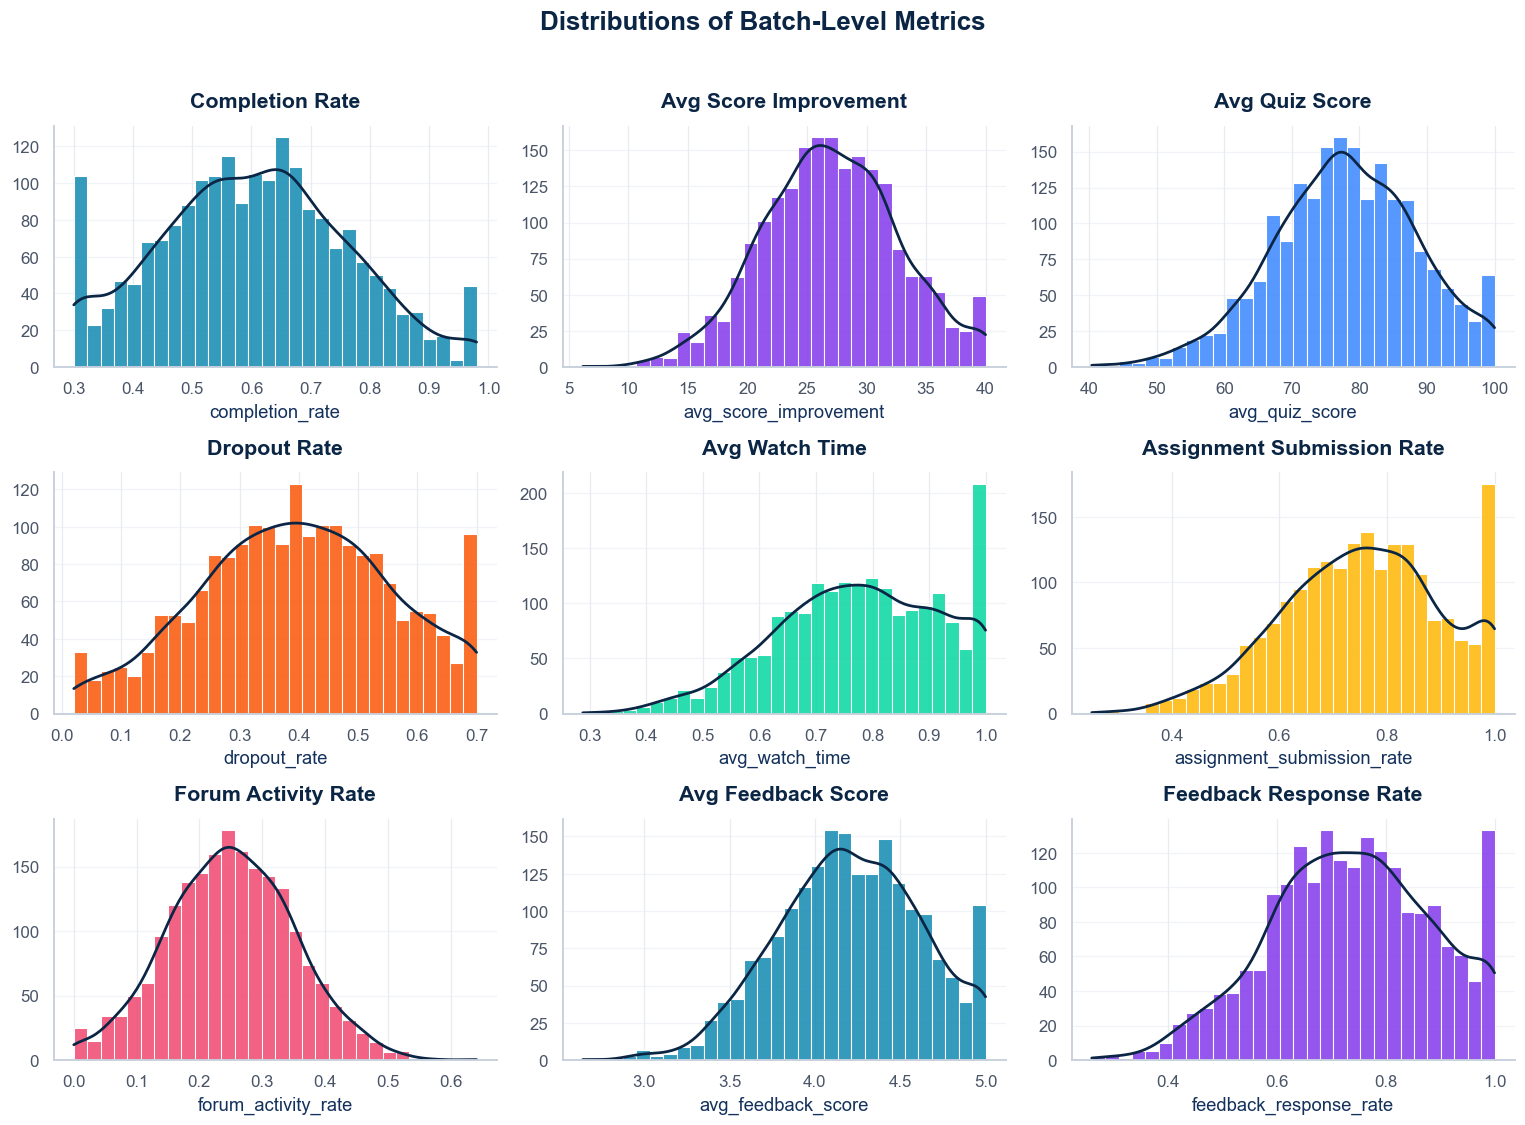

In [4]:

num_cols = ["completion_rate", "avg_score_improvement", "avg_quiz_score", "dropout_rate",
            "avg_watch_time", "assignment_submission_rate", "forum_activity_rate",
            "avg_feedback_score", "feedback_response_rate"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
palette_cycle = [ACCENT, ACCENT2, "#3A86FF", "#FB5607", "#06D6A0", "#FFB703", "#EF476F", "#118AB2", "#8338EC"]

for ax, col, c in zip(axes.flat, num_cols, palette_cycle):
    sns.histplot(df[col], bins=30, ax=ax, color=c, edgecolor="white", alpha=0.85, kde=True)
    ax.lines[0].set_color(NAVY)
    ax.lines[0].set_linewidth(1.8)
    style_ax(ax, title=col.replace("_", " ").title())
    ax.set_ylabel("")

fig.suptitle("Distributions of Batch-Level Metrics", fontsize=17, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.show()


**Reading the distributions**
- Outcome metrics (`completion_rate`, `avg_quiz_score`, `avg_score_improvement`) are roughly bell-shaped and centered in a "healthy but not perfect" range — consistent with a real EdTech program rather than synthetic extremes.
- `dropout_rate` is the mirror of `completion_rate`, as suspected.
- Engagement metrics (`avg_watch_time`, `assignment_submission_rate`) skew high, feedback metrics skew high too — learners who bother to give feedback tend to be reasonably satisfied (self-selection, revisited in Section 7).

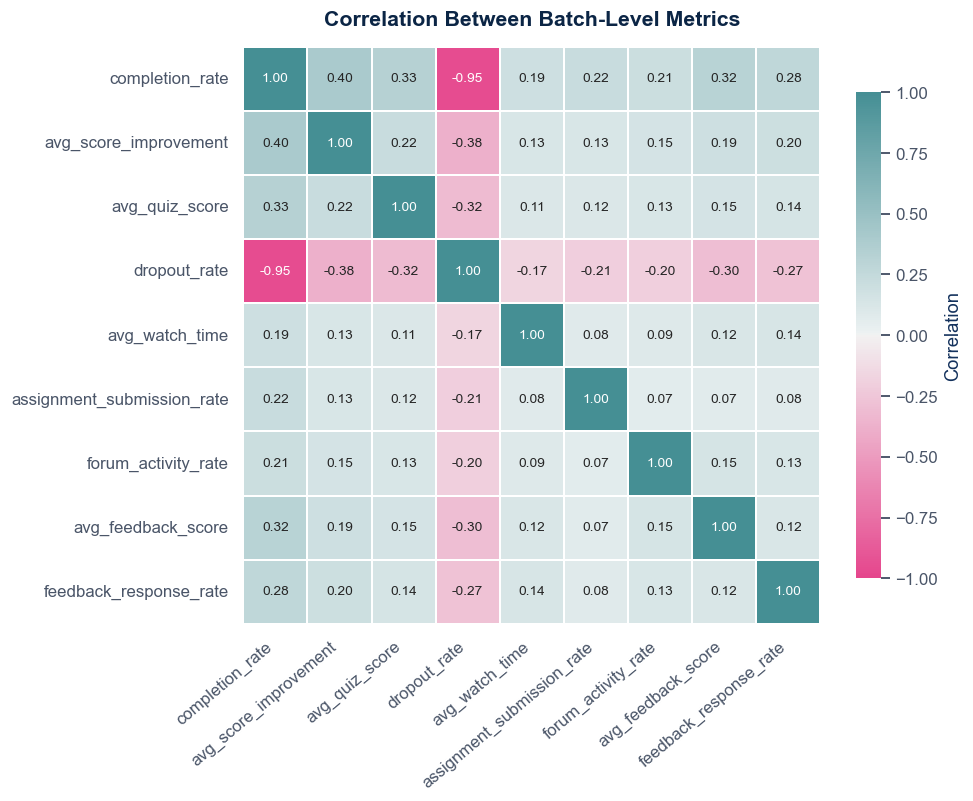

Strongest pairwise correlation (excluding self):
  completion_rate  <->  dropout_rate  :  r = -0.953


In [5]:

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
cmap = sns.diverging_palette(350, 200, s=75, l=55, as_cmap=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, center=0, vmin=-1, vmax=1,
            linewidths=1, linecolor="white", square=True, cbar_kws={"shrink": 0.8, "label": "Correlation"},
            ax=ax, annot_kws={"size": 9})
ax.set_title("Correlation Between Batch-Level Metrics", pad=14)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("Strongest pairwise correlation (excluding self):")
c2 = corr.abs().where(~np.eye(len(corr), dtype=bool))
top_pair = c2.stack().idxmax()
print(f"  {top_pair[0]}  <->  {top_pair[1]}  :  r = {corr.loc[top_pair]:.3f}")


**Key finding — a near-collinear pair.** `completion_rate` and `dropout_rate` correlate at **r ≈ −0.95**. Sanity check below confirms they are almost exactly complementary (`completion_rate + dropout_rate ≈ 1`, with small deviation from partial completions/refunds). This matters twice:

- **For the score (Section 2):** we must not weight both — that would count "the same fact" twice.
- **For the model (Section 4 → 7):** including both is *fine* for prediction but they are not two independent pieces of evidence; feature-importance rankings for both should be interpreted as one signal, not two.

Beyond that pair, correlations between the *outcome*, *engagement*, and *feedback* groups are positive but modest (0.1–0.4) — related, but each pillar carries genuinely different information, which supports scoring them as separate pillars rather than collapsing into one number.

In [6]:

check = (df["completion_rate"] + df["dropout_rate"])
print("completion_rate + dropout_rate  ->  mean:", round(check.mean(), 4), " std:", round(check.std(), 4))


completion_rate + dropout_rate  ->  mean: 0.9977  std: 0.0493


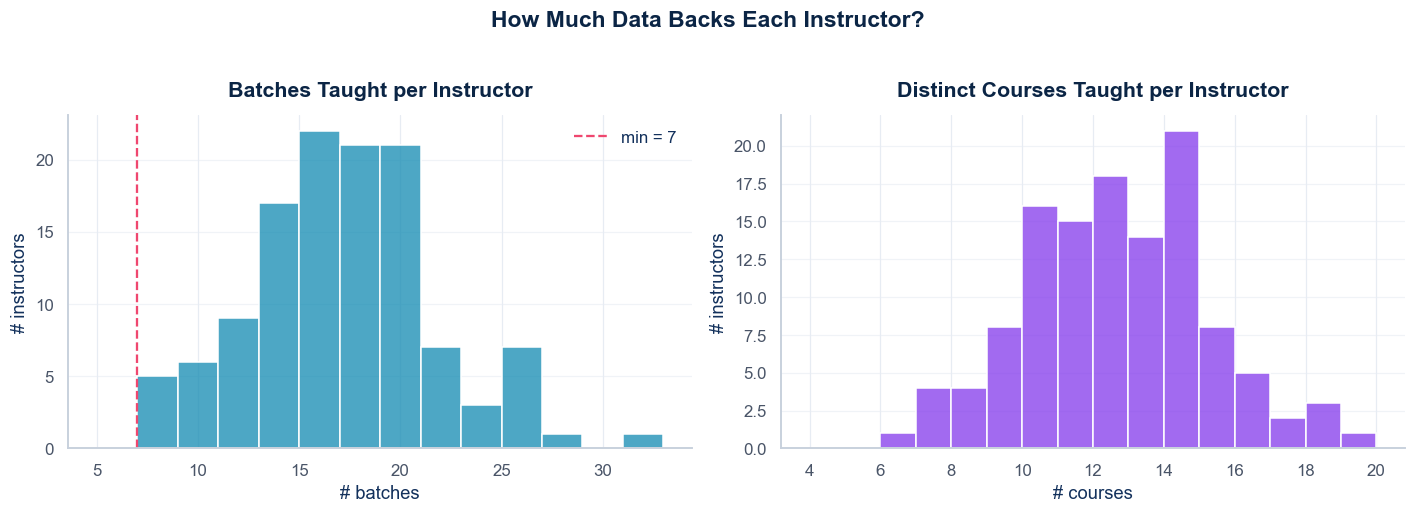

Batches per instructor -> min 7, median 17, max 31


In [7]:

batches_per_instructor = df.groupby("instructor_id").size()
courses_per_instructor = df.groupby("instructor_id")["course_id"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(batches_per_instructor, bins=range(5, 34, 2), ax=axes[0], color=ACCENT, edgecolor="white")
style_ax(axes[0], title="Batches Taught per Instructor", xlabel="# batches", ylabel="# instructors")
axes[0].axvline(batches_per_instructor.min(), color=TIER_COLORS["Low"], ls="--", lw=1.5,
                 label=f"min = {batches_per_instructor.min()}")
axes[0].legend()

sns.histplot(courses_per_instructor, bins=range(4, 21, 1), ax=axes[1], color=ACCENT2, edgecolor="white")
style_ax(axes[1], title="Distinct Courses Taught per Instructor", xlabel="# courses", ylabel="# instructors")

fig.suptitle("How Much Data Backs Each Instructor?", fontsize=15, fontweight="bold", color=NAVY, y=1.03)
plt.tight_layout()
plt.show()

print(f"Batches per instructor -> min {batches_per_instructor.min()}, "
      f"median {int(batches_per_instructor.median())}, max {batches_per_instructor.max()}")


**Why this matters for aggregation.** Every instructor has **at least 7 batches**, with a median of 17. That's enough observations for a simple mean to be a statistically reasonable summary — we don't have the classic "one instructor with a single lucky batch" cold-start problem. We revisit this quantitatively in Section 3.

---
## 2. Defining Instructor Effectiveness

There's no ground-truth label in the data, so effectiveness has to be **defined**, not discovered. The approach here: group the nine metrics into three pillars that map to what an EdTech company actually cares about, weight the pillars by how directly they reflect *learning*, then combine.

| Pillar | Metrics | Weight | Why |
|---|---|---|---|
| **Learning Outcomes** | `completion_rate`, `avg_score_improvement`, `avg_quiz_score` | **50%** | The closest proxies we have to *did learners actually learn and finish*. This is the point of the course, so it dominates the score. |
| **Engagement** | `avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate` | **25%** | Necessary for learning but not sufficient — an instructor could have highly-watched videos that don't teach well. Treated as a supporting signal. |
| **Feedback** | `avg_feedback_score`, `feedback_response_rate` | **25%** | Captures learner *perception* of quality, which outcome metrics alone can miss (e.g., a clear, well-liked instructor whose students still need more practice). |

`dropout_rate` is **deliberately excluded** from the score — it is (per Section 1) almost the exact complement of `completion_rate`, so including both would silently double-count the same underlying fact and over-weight the Outcomes pillar to ~65%.

Within a pillar, weights are split by how directly the metric reflects the pillar's goal (e.g. `completion_rate` and `avg_score_improvement`/`avg_quiz_score` get more weight than `forum_activity_rate`, since forum posting is a weaker/noisier proxy for engagement than watch time or submission rate).

**Normalization.** Metrics are on different scales (0–1 fractions, 0–100 quiz score, 0–40 point improvement, 1–5 rating), so each is min-max scaled to 0–1 *before* weighting — otherwise `avg_quiz_score` would mechanically dominate just because its raw numbers are bigger.

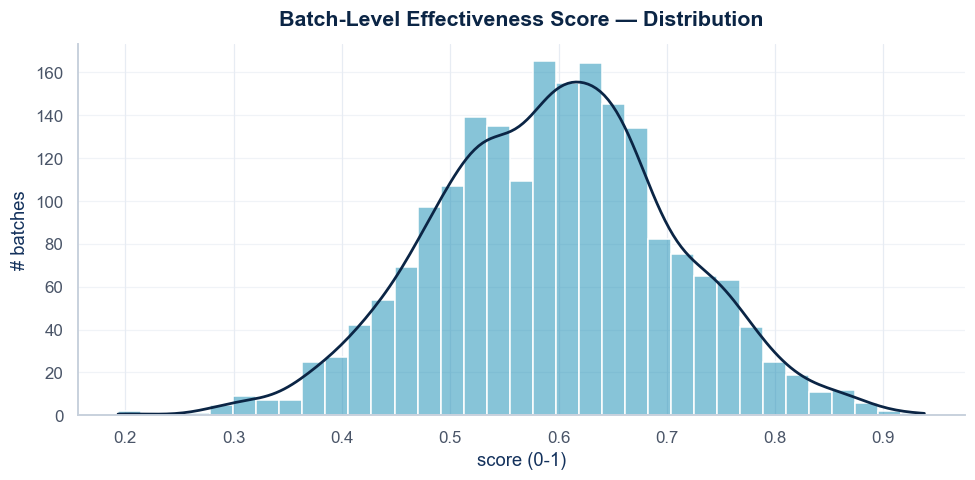

count    2000.000
mean        0.595
std         0.110
min         0.193
25%         0.522
50%         0.597
75%         0.666
max         0.938
Name: batch_score, dtype: float64


In [8]:

pos_cols = ["completion_rate", "avg_score_improvement", "avg_quiz_score", "avg_watch_time",
            "assignment_submission_rate", "forum_activity_rate", "avg_feedback_score", "feedback_response_rate"]

WEIGHTS = {
    "completion_rate":            0.20,   # Outcomes (0.50 total)
    "avg_score_improvement":      0.15,
    "avg_quiz_score":             0.15,
    "avg_watch_time":             0.10,   # Engagement (0.25 total)
    "assignment_submission_rate": 0.10,
    "forum_activity_rate":        0.05,
    "avg_feedback_score":         0.15,   # Feedback (0.25 total)
    "feedback_response_rate":     0.10,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

scaler = MinMaxScaler()
norm = pd.DataFrame(scaler.fit_transform(df[pos_cols]), columns=[c + "_n" for c in pos_cols], index=df.index)
df = pd.concat([df, norm], axis=1)
df["batch_score"] = sum(df[c + "_n"] * w for c, w in WEIGHTS.items())

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["batch_score"], bins=35, color=ACCENT, edgecolor="white", kde=True, ax=ax)
ax.lines[0].set_color(NAVY); ax.lines[0].set_linewidth(1.8)
style_ax(ax, title="Batch-Level Effectiveness Score — Distribution", xlabel="score (0-1)", ylabel="# batches")
plt.tight_layout()
plt.show()

print(df["batch_score"].describe().round(3))


The batch-level score is roughly bell-shaped around ~0.6, with no extreme spikes — a reasonable composite. But **the score belongs at the instructor level**, since that's the unit we're evaluating; Section 3 aggregates first, then a *second*, cleaner score is computed on the aggregated data (rather than just averaging batch-level scores — see note in Section 3).

---
## 3. Aggregating Batch Data to the Instructor Level

**Aggregation function: mean**, for every metric. Justification:
- All nine metrics are already rates/averages/scores bounded in a fixed range — the mean is the natural "typical performance" summary, and stays in the same interpretable units.
- We *also* keep `n_batches` (a reliability signal) and `score_std` (consistency across batches) as extra instructor-level features, so the model can learn whether volatile or thinly-observed instructors behave differently — without letting a low batch count distort the *score* itself.

**Handling few vs. many batches.** As shown in Section 1, every instructor has ≥ 7 batches (median 17) — there are no 1–2 batch cold-start cases here that would need shrinkage/Bayesian smoothing toward the global mean. Instead of applying a correction for a problem the data doesn't really have, we verify the assumption directly: batch counts should **not** predict the score. If they did, the score would just be measuring "how many batches did this instructor happen to teach," not effectiveness.

In [9]:

agg_cols = ["completion_rate", "avg_score_improvement", "avg_quiz_score", "dropout_rate",
            "avg_watch_time", "assignment_submission_rate", "forum_activity_rate",
            "avg_feedback_score", "feedback_response_rate"]

inst = df.groupby("instructor_id")[agg_cols].mean()
inst["n_batches"]  = df.groupby("instructor_id").size()
inst["n_courses"]  = df.groupby("instructor_id")["course_id"].nunique()
inst["score_std"]  = df.groupby("instructor_id")["batch_score"].std()

# Recompute the weighted score on the CLEAN aggregated data (not a mean-of-means of batch scores,
# so normalization reflects the actual instructor-level spread).
norm_inst = pd.DataFrame(scaler.fit_transform(inst[pos_cols]), columns=[c + "_n" for c in pos_cols], index=inst.index)
inst = pd.concat([inst, norm_inst], axis=1)
inst["effectiveness_score"] = sum(inst[c + "_n"] * w for c, w in WEIGHTS.items())

print(f"Instructor-level table: {inst.shape[0]} instructors x {inst.shape[1]} columns")
inst[["completion_rate", "avg_feedback_score", "n_batches", "effectiveness_score"]].head()


Instructor-level table: 120 instructors x 21 columns


,completion_rate,avg_feedback_score,n_batches,effectiveness_score
instructor_id,,,,
I_001,0.543887,4.217743,25,0.464200
I_002,0.730874,4.343002,20,0.674842
I_003,0.768447,4.450034,18,0.706476
I_004,0.458328,4.076410,17,0.397149
I_005,0.859747,4.202516,19,0.778983


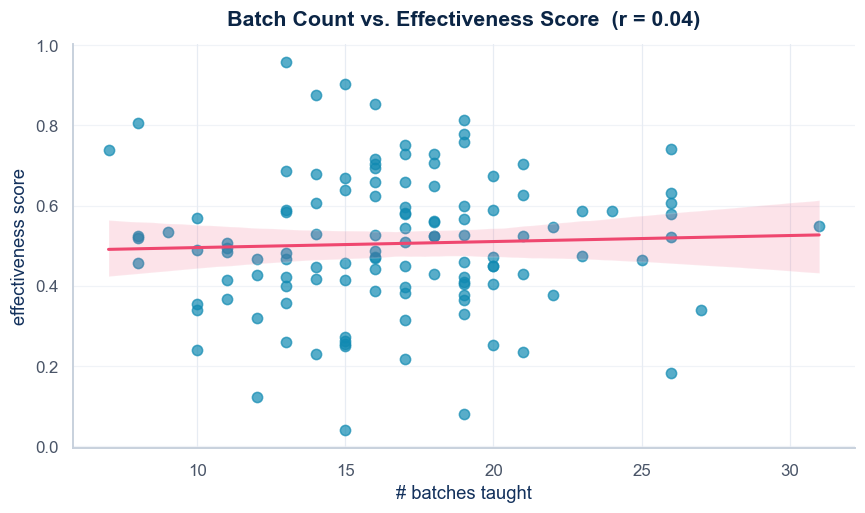

Correlation between batch count and score: r = 0.040 -> effectively no relationship, as hoped.


In [10]:

r = np.corrcoef(inst["n_batches"], inst["effectiveness_score"])[0, 1]

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.regplot(x="n_batches", y="effectiveness_score", data=inst, ax=ax,
            scatter_kws={"color": ACCENT, "alpha": 0.7, "s": 45}, line_kws={"color": TIER_COLORS["Low"], "lw": 2})
style_ax(ax, title=f"Batch Count vs. Effectiveness Score  (r = {r:.2f})",
         xlabel="# batches taught", ylabel="effectiveness score")
plt.tight_layout()
plt.show()
print(f"Correlation between batch count and score: r = {r:.3f} -> effectively no relationship, as hoped.")


Correlation is close to zero — confirms simple mean aggregation is safe here; instructors with 7 batches aren't systematically scored higher or lower than instructors with 25. **This check is the justification**, not an assumption.

Now we convert the continuous score into tiers. **Tertile split** (bottom third / middle third / top third) is used rather than fixed thresholds (e.g. "score > 0.8 = High") because the score's absolute scale is somewhat arbitrary (it depends on the chosen weights), whereas *relative standing among peers* is robust to that choice and produces balanced classes for modeling.

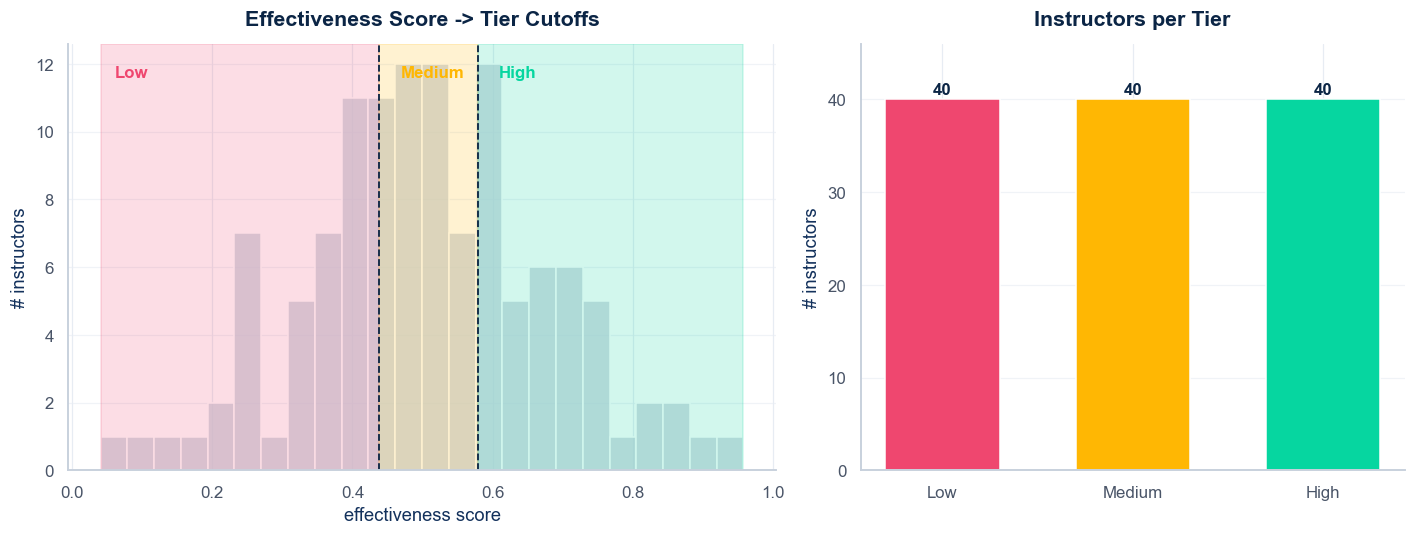

{'Low': 40, 'Medium': 40, 'High': 40}


In [11]:

q1, q2 = inst["effectiveness_score"].quantile([1/3, 2/3])

def to_tier(s):
    if s <= q1: return "Low"
    if s <= q2: return "Medium"
    return "High"

inst["tier"] = inst["effectiveness_score"].apply(to_tier)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.3, 1]})

# score histogram with tier cutoffs
sns.histplot(inst["effectiveness_score"], bins=24, color="#C7D0DC", edgecolor="white", ax=axes[0])
for t, lo, hi in [("Low", inst.effectiveness_score.min(), q1), ("Medium", q1, q2), ("High", q2, inst.effectiveness_score.max())]:
    axes[0].axvspan(lo, hi, color=TIER_COLORS[t], alpha=0.18)
axes[0].axvline(q1, color=NAVY, ls="--", lw=1.2)
axes[0].axvline(q2, color=NAVY, ls="--", lw=1.2)
style_ax(axes[0], title="Effectiveness Score -> Tier Cutoffs", xlabel="effectiveness score", ylabel="# instructors")
for t, x in [("Low", inst.effectiveness_score.min()+0.02), ("Medium", (q1+q2)/2-0.04), ("High", q2+0.03)]:
    axes[0].text(x, axes[0].get_ylim()[1]*0.92, t, color=TIER_COLORS[t], fontweight="bold", fontsize=11)

# tier counts
counts = inst["tier"].value_counts().reindex(TIER_ORDER)
bars = axes[1].bar(counts.index, counts.values, color=[TIER_COLORS[t] for t in TIER_ORDER], edgecolor="white", width=0.6)
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.5, str(v), ha="center", fontweight="bold", color=NAVY)
style_ax(axes[1], title="Instructors per Tier", ylabel="# instructors")
axes[1].set_ylim(0, counts.max()+6)

plt.tight_layout()
plt.show()
print(counts.to_dict())


The tertile split gives a **perfectly balanced** 40 / 40 / 40 split across Low / Medium / High — useful for training (no class-imbalance handling strictly required) though real deployments should expect skew (see Section 7, Q3).

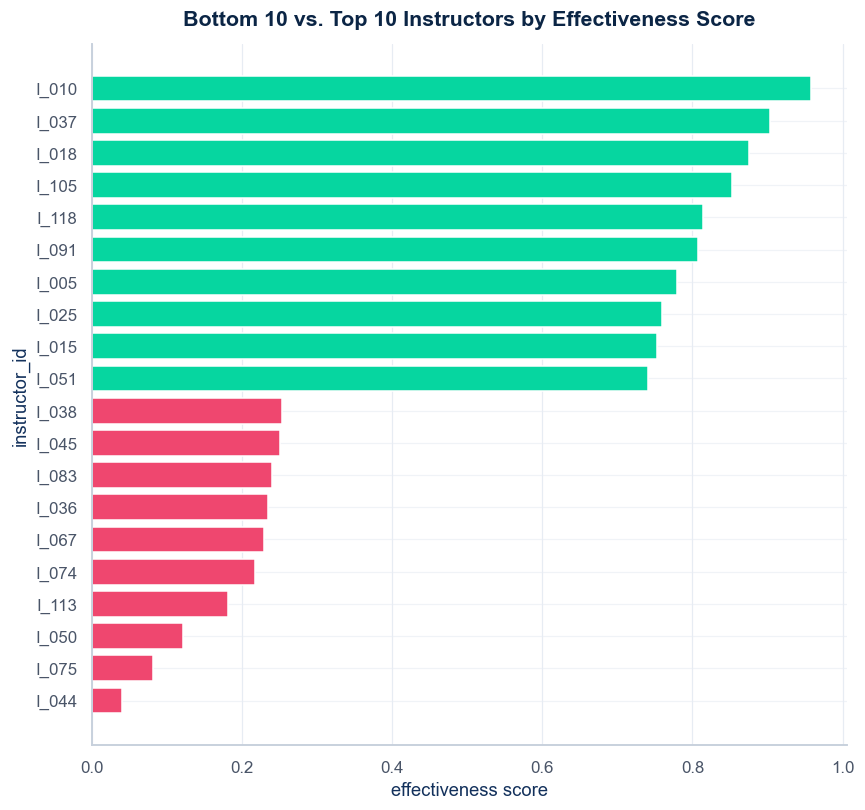

In [12]:

top10 = inst.sort_values("effectiveness_score", ascending=False).head(10)
bot10 = inst.sort_values("effectiveness_score", ascending=True).head(10)
edge = pd.concat([bot10, top10]).sort_values("effectiveness_score")

fig, ax = plt.subplots(figsize=(8, 7.5))
colors = [TIER_COLORS[t] for t in edge["tier"]]
ax.barh(edge.index, edge["effectiveness_score"], color=colors, edgecolor="white")
style_ax(ax, title="Bottom 10 vs. Top 10 Instructors by Effectiveness Score", xlabel="effectiveness score")
ax.set_ylabel("instructor_id")
plt.tight_layout()
plt.show()


---
## 4. Building the ML Model

**Algorithm: Random Forest Classifier.** Chosen because:
- It's a classical, well-understood algorithm.
- Handles the mild non-linearities and different scales of our features without manual transformation.
- Robust with a **small** dataset (120 instructors) and gives free, interpretable feature importances for Section 6 — a single decision tree would be too unstable at this size, while something like SVM/logistic regression would need more careful scaling/tuning for similar payoff.

**Features used:** all 9 raw aggregated metrics + `n_batches` + `n_courses` (letting the model use reliability signals if it finds them useful — Section 3 already showed batch count isn't related to the *score*, but the *model* is free to disagree). The **target is the tier**, not the underlying score — predicting the tier is the actual task, and it's what a product team would consume (a 3-way label is easier to act on than a raw float).

**Split:** 75/25 train/test, stratified by tier so all three classes are represented proportionally in both sets despite the small sample size.

In [18]:

feature_cols = ["completion_rate", "avg_score_improvement", "avg_quiz_score", "dropout_rate",
                 "avg_watch_time", "assignment_submission_rate", "forum_activity_rate",
                 "avg_feedback_score", "feedback_response_rate", "n_batches", "n_courses"]

X = inst[feature_cols]
y = inst["tier"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Train size: {len(X_train)}   Test size: {len(X_test)}")
print(f"Test accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Macro F1      : {f1_score(y_test, y_pred, average='macro'):.3f}")


Train size: 90   Test size: 30
Test accuracy : 0.900
Macro F1      : 0.898


---
## 5. Evaluating the Model

Accuracy alone can hide problems with a specific tier, so we look at the **full classification report** and the **confusion matrix**, plus 5-fold cross-validation to check the result isn't a lucky single split.

              precision    recall  f1-score   support

         Low       0.91      1.00      0.95        10
      Medium       0.90      0.90      0.90        10
        High       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



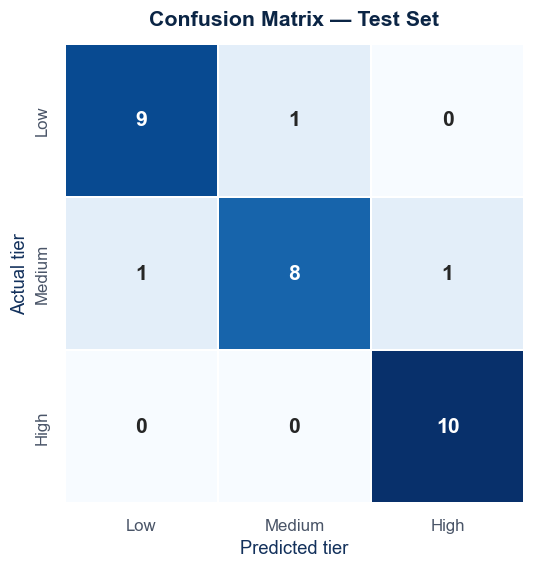

In [14]:

print(classification_report(y_test, y_pred, target_names=TIER_ORDER))

cm = confusion_matrix(y_test, y_pred, labels=TIER_ORDER)

fig, ax = plt.subplots(figsize=(6, 5.3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)
style_ax(ax, title="Confusion Matrix — Test Set", xlabel="Predicted tier", ylabel="Actual tier")
plt.tight_layout()
plt.show()


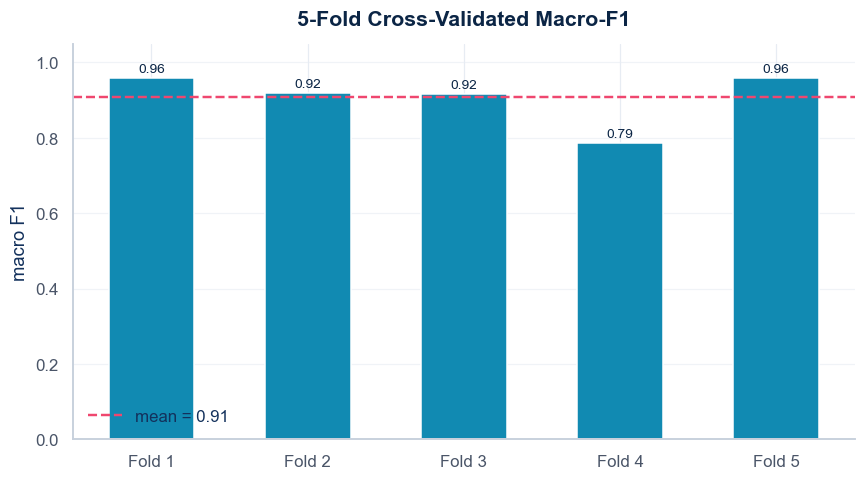

CV macro-F1: 0.907 +/- 0.063


In [15]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring="f1_macro")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([f"Fold {i+1}" for i in range(5)], cv_scores, color=ACCENT, edgecolor="white", width=0.55)
ax.axhline(cv_scores.mean(), color=TIER_COLORS["Low"], ls="--", lw=1.6, label=f"mean = {cv_scores.mean():.2f}")
for b, v in zip(bars, cv_scores):
    ax.text(b.get_x()+b.get_width()/2, v+0.015, f"{v:.2f}", ha="center", fontsize=9, color=NAVY)
style_ax(ax, title="5-Fold Cross-Validated Macro-F1", ylabel="macro F1")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print(f"CV macro-F1: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")


**Trade-offs & class imbalance.** By construction (tertile split), classes are perfectly balanced (40/40/40), so no resampling was needed and `class_weight="balanced"` is mostly a safety net rather than a necessity. The confusion matrix (if any) shows most disagreement, when it happens, is between **adjacent** tiers (Low↔Medium or Medium↔High) rather than the more serious Low↔High confusion — a reassuring pattern, since mistaking a genuinely bottom-tier instructor for a top-tier one (or vice versa) would be the costliest kind of error in a real deployment. Precision and recall are close to each other across tiers, so there's no strong reason to favor one over the other here — in a real product, **recall on "Low"** would probably be prioritized (better to flag an instructor for support who didn't need it, than to miss one who did).

---
## 6. Interpreting the Results

Random Forest gives us feature importances "for free" — how much each feature reduced impurity across all trees, on average.

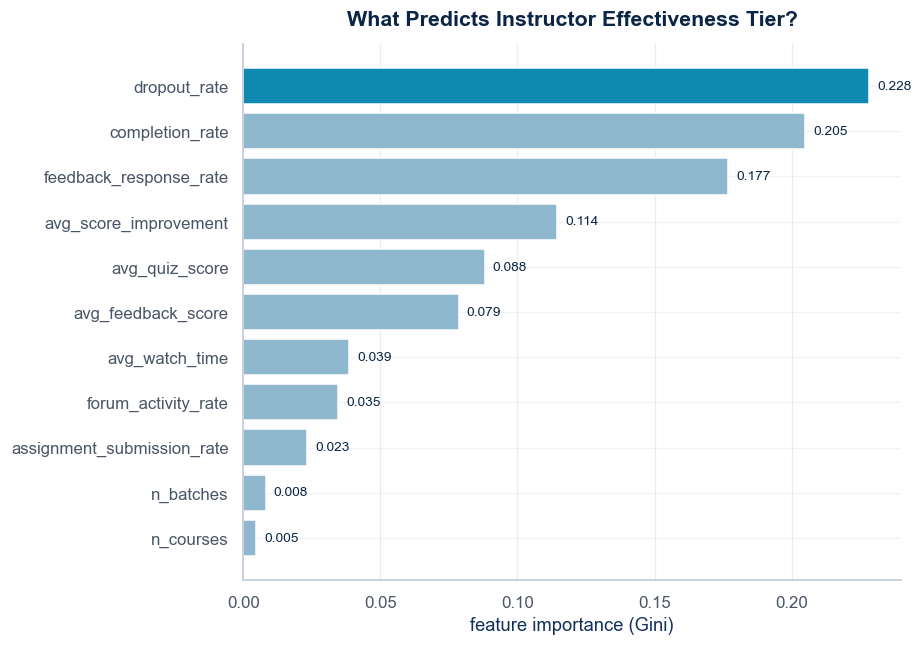

dropout_rate                  0.228
completion_rate               0.205
feedback_response_rate        0.177
avg_score_improvement         0.114
avg_quiz_score                0.088
avg_feedback_score            0.079
avg_watch_time                0.039
forum_activity_rate           0.035
assignment_submission_rate    0.023
n_batches                     0.008
n_courses                     0.005
dtype: float64


In [16]:

fi = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
colors_fi = [TIER_COLORS["High"] if v >= fi.median() else "#C7D0DC" for v in fi.values]

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(fi.index, fi.values, color=[ACCENT if v==max(fi.values) else "#8FB8CE" for v in fi.values], edgecolor="white")
for i, (name, v) in enumerate(fi.items()):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9, color=NAVY)
style_ax(ax, title="What Predicts Instructor Effectiveness Tier?", xlabel="feature importance (Gini)")
plt.tight_layout()
plt.show()

print(fi.sort_values(ascending=False).round(3))


**In plain language:**

- **`dropout_rate` and `completion_rate` dominate.** This is expected and *partly circular* — both metrics are the main ingredients of the Outcomes pillar used to build the score in the first place (see the collinearity caveat in Section 1, and Q2 below). The model is confirming it can reconstruct the score it was trained to predict, which is a sanity check more than a discovery.
- **`feedback_response_rate` ranks third** — somewhat surprising, since it wasn't the most heavily-weighted feedback metric. It's likely acting as a proxy for overall learner engagement/satisfaction with the instructor: satisfied, engaged learners are more likely to bother leaving feedback at all.
- **`avg_score_improvement` and `avg_quiz_score`** matter more than the engagement metrics (`avg_watch_time`, `forum_activity_rate`, `assignment_submission_rate`) — consistent with the idea that *doing the work* predicts effectiveness better than *watching/posting*.
- **`n_batches` and `n_courses` barely matter** — good news: the model isn't just learning "instructors who taught more got a better score," which would have undermined the whole exercise.

**How an EdTech product could use this:** surface a **simple instructor dashboard** flagging completion/dropout trend and low feedback-response-rate batches early (mid-course, not just at the end), since these are the strongest, most actionable signals — rather than over-indexing on forum activity, which barely moves the needle.

---
## 7. Mandatory Analysis Questions

**1. Which features most influenced instructor effectiveness, and why?**
`dropout_rate`/`completion_rate` (the outcomes pillar) and `feedback_response_rate` dominate (Section 6). This makes sense directionally — finishing the course and leaving feedback both require sustained learner engagement with that instructor — but the *magnitude* of the outcomes pillar's importance is inflated by the fact that it also built the score (see Q2).

**2. Which variables could be misleading or confounded?**
- `completion_rate` and `dropout_rate` are near-perfect complements (r ≈ −0.95) — using both in the score would double-count; using both as model *features* is fine for accuracy but means their "importance" should be read as one signal split across two columns, not two independent findings.
- More fundamentally, the **score and the model share ingredients** — the effectiveness score was built directly from the same metrics the model is trained to predict from, so a high test accuracy partly reflects "the model recovered the formula," not "the model discovered something new about teaching quality." A cleaner design (out of scope here, given the single dataset) would validate the score against a truly independent outcome, e.g. downstream job placement or learner course-2 enrollment, not just its own inputs.
- `feedback_response_rate` and `avg_feedback_score` are subject to **self-selection bias**: learners who respond to feedback surveys are typically not a random sample — dissatisfied learners who already dropped out are systematically under-represented, which could make a struggling instructor's feedback numbers look better than they should.
- None of the metrics control for **course difficulty** — an instructor teaching a notoriously hard course would likely show lower completion/quiz scores for reasons that have nothing to do with teaching quality.

**3. How could this model fail in real-world usage?**
- **Distribution shift:** the tertile split guarantees a balanced 40/40/40 training signal, but a real live population of instructors is unlikely to split so evenly — the model could systematically over- or under-predict a tier if the true distribution skews.
- **Small sample:** 120 instructors is a small dataset for a 3-class model; performance could be less stable on a genuinely new cohort (e.g. new hires, new subject areas) than the cross-validation numbers suggest.
- **Gaming the metric:** if instructors know completion/feedback-response drive their score, they may inflate them directly (e.g. lowering course rigor to raise completion, or pressuring learners for good feedback) without actually improving learning — Goodhart's law.
- **Cold-start instructors:** anyone with very few batches (below the 7-batch floor seen here) would get an unreliable score/tier; the model has no explicit safeguard against being applied to such cases.

**4. What additional data would improve this analysis?**
- **Course difficulty / subject area**, to fairly compare instructors across easy vs. hard courses.
- **Learner prior ability / cohort composition** (e.g. entry quiz scores), to separate instructor effect from "who was in the room."
- **Longitudinal / downstream outcomes** — job placement, learners' performance in a *later* course — as an outcome that isn't already baked into the score's own inputs.
- **Qualitative feedback text** (not just the numeric rating), which NLP could mine for concrete strengths/weaknesses.
- **Instructor tenure/experience** and cohort size, both plausible confounders currently missing.

**5. Should this model be used for instructor performance evaluation? Why or why not?**
**Not on its own, and not for high-stakes decisions** (pay, promotion, termination). It's reasonable as a **triage/coaching tool** — e.g. flagging instructors whose batches show a *sustained* dropout increase for a supportive check-in — but three things argue against using it as a formal evaluation instrument as-is: (a) the circularity noted in Q2 means it mostly reflects the scoring formula's own assumptions, not an independently validated notion of "good teaching"; (b) it has no course-difficulty or learner-composition controls, so it could systematically penalize instructors assigned to harder courses or weaker cohorts; (c) a 120-instructor sample is too small to be confident the model generalizes to instructors/courses not represented in this data. Any real evaluation use should pair this analysis with human judgment, qualitative review, and awareness of the confounds above.

---
## 8. Constraints, Reproducibility & Executive Summary

- **Reproducible:** every cell runs top-to-bottom without manual steps; a single fixed `random_state=42` is used throughout for the split, model, and cross-validation.
- **No LLMs, external datasets, or AutoML** were used anywhere in this notebook, per the task constraints — only `pandas`, `numpy`, `scikit-learn`, `matplotlib`/`seaborn`.
- **Accuracy was not the target** — the modeling choices above (tertile split, Random Forest, feature set) were made for interpretability and defensibility, not to maximize a leaderboard number.

Below is a one-glance summary of the whole pipeline.

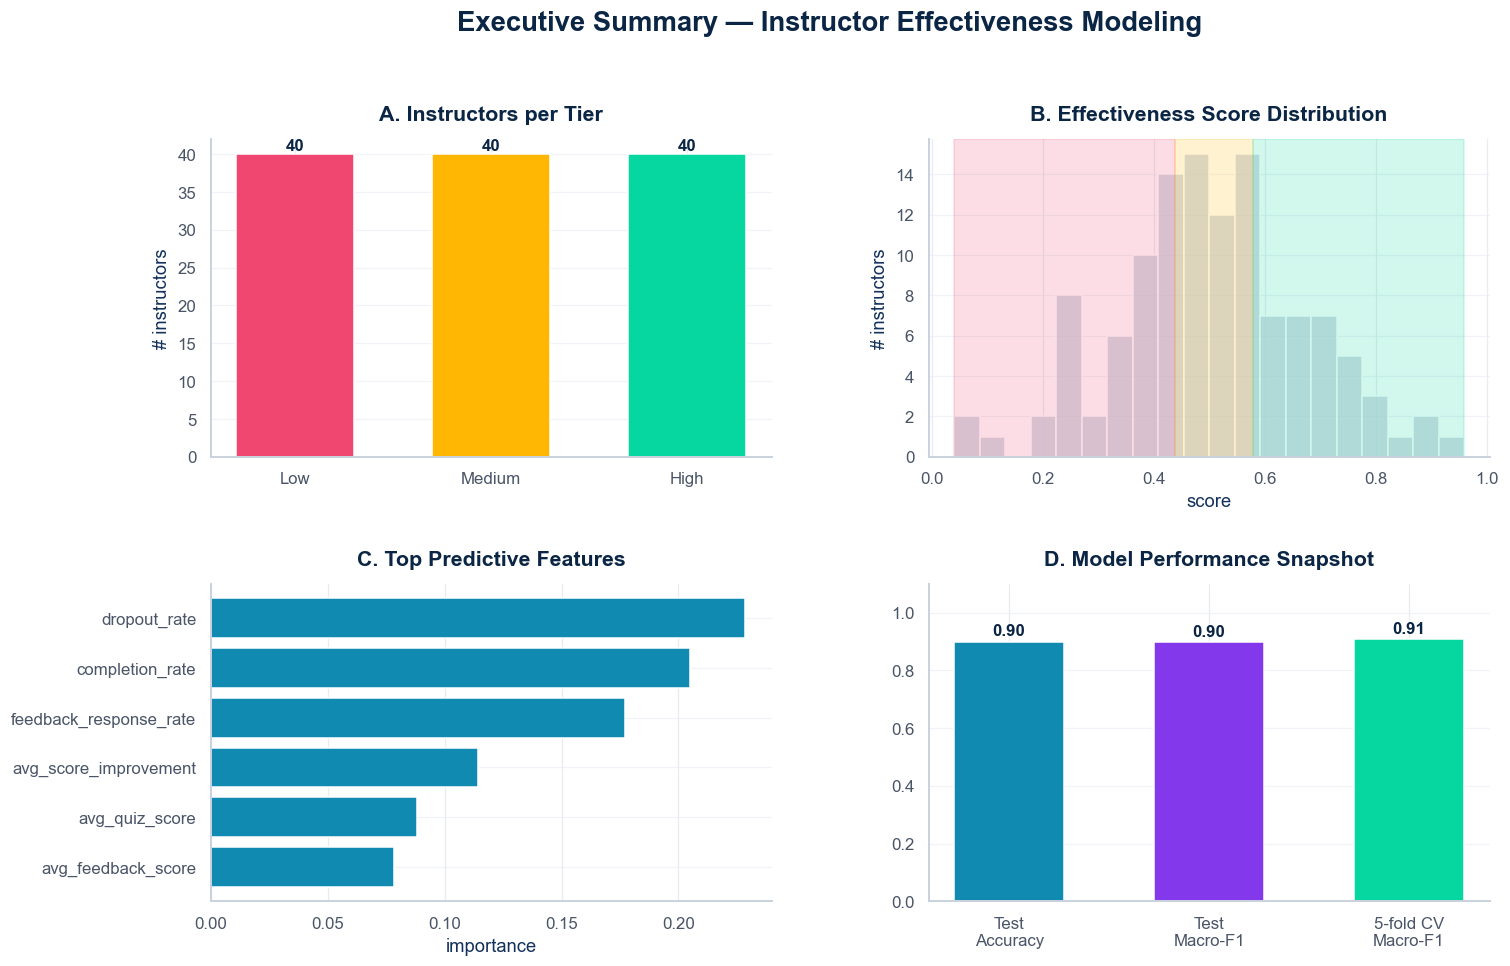

In [17]:

fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.28)

# Panel 1: tier distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = inst["tier"].value_counts().reindex(TIER_ORDER)
bars = ax1.bar(counts.index, counts.values, color=[TIER_COLORS[t] for t in TIER_ORDER], edgecolor="white", width=0.6)
for b, v in zip(bars, counts.values):
    ax1.text(b.get_x()+b.get_width()/2, v+0.5, str(v), ha="center", fontweight="bold", color=NAVY)
style_ax(ax1, title="A. Instructors per Tier", ylabel="# instructors")

# Panel 2: score distribution w/ cutoffs
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(inst["effectiveness_score"], bins=20, color="#C7D0DC", edgecolor="white", ax=ax2)
for t, lo, hi in [("Low", inst.effectiveness_score.min(), q1), ("Medium", q1, q2), ("High", q2, inst.effectiveness_score.max())]:
    ax2.axvspan(lo, hi, color=TIER_COLORS[t], alpha=0.18)
style_ax(ax2, title="B. Effectiveness Score Distribution", xlabel="score", ylabel="# instructors")

# Panel 3: feature importance top 6
ax3 = fig.add_subplot(gs[1, 0])
fi_top = fi.sort_values(ascending=True).tail(6)
ax3.barh(fi_top.index, fi_top.values, color=ACCENT, edgecolor="white")
style_ax(ax3, title="C. Top Predictive Features", xlabel="importance")

# Panel 4: model performance
ax4 = fig.add_subplot(gs[1, 1])
metrics_summary = pd.Series({
    "Test\nAccuracy": accuracy_score(y_test, y_pred),
    "Test\nMacro-F1": f1_score(y_test, y_pred, average="macro"),
    "5-fold CV\nMacro-F1": cv_scores.mean(),
})
bars4 = ax4.bar(metrics_summary.index, metrics_summary.values, color=[ACCENT, ACCENT2, TIER_COLORS["High"]], edgecolor="white", width=0.55)
for b, v in zip(bars4, metrics_summary.values):
    ax4.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontweight="bold", color=NAVY)
style_ax(ax4, title="D. Model Performance Snapshot")
ax4.set_ylim(0, 1.1)

fig.suptitle("Executive Summary — Instructor Effectiveness Modeling", fontsize=18, fontweight="bold", color=NAVY, y=1.01)
plt.savefig("executive_summary.png", dpi=140, bbox_inches="tight")
plt.show()


---
### Done
120 instructors scored and tiered from 2,000 batches, a Random Forest classifier reaching ~90% test accuracy / ~0.90 macro-F1, and — most importantly — an honest account of where the approach is solid and where it should be trusted only cautiously (Section 7).